<a href="https://colab.research.google.com/github/gibbsiara/Projekt-Wyzwanie-Solvro/blob/gibbsiara-dev/statsbomb_model/xG_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install statsbombpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.8/63.8 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.8/70.8 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.8/74.8 kB 3.7 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsbombpy import sb
import numpy as np
import math

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
GOOGLE_DRIVE_PATH = "/content/drive/MyDrive/statsbomb_data"
FILE_PATH = os.path.join(GOOGLE_DRIVE_PATH, "all_statsbomb_shots.pkl")

In [ ]:
import pandas as pd
import math
from sklearn.preprocessing import OneHotEncoder, StandardScaler


class model_pipeline:

    CATEGORICAL_COLS = ['play_pattern', 'shot_type', 'shot_body_part', 'shot_technique', 'position']

    def __init__(self, X_train, X_test, y_train, y_test):
        X_train_processed = self.process_pipeline(X_train)
        X_test_processed = self.process_pipeline(X_test)

        self.encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
        self.encoder.fit(X_train_processed[self.CATEGORICAL_COLS])
        self.std_scaler = StandardScaler()


        X_train_encoded = self.encode_categoricals(X_train_processed)
        X_test_encoded = self.encode_categoricals(X_test_processed)

        self.std_scaler = StandardScaler()
        self.std_scaler.fit(X_train_encoded)

        self.X_train = self.std_scaler.transform(X_train_encoded)
        self.X_test = self.std_scaler.transform(X_test_encoded)

        self.y_train = y_train
        self.y_test = y_test

    def encode_categoricals(self, df):
        encoded_array = self.encoder.transform(df[self.CATEGORICAL_COLS])
        encoded_cols = self.encoder.get_feature_names_out(self.CATEGORICAL_COLS)
        encoded_df = pd.DataFrame(encoded_array, columns=encoded_cols, index=df.index)

        df = df.drop(columns=self.CATEGORICAL_COLS)
        df = pd.concat([df, encoded_df], axis=1)
        return df

    def process_pipeline(self, dataframe_to_pipeline):
        dataframe_to_pipeline_copy = dataframe_to_pipeline.copy()

        dataframe_to_pipeline_copy = self.code_shot_location_data(dataframe_to_pipeline_copy)
        dataframe_to_pipeline_copy = self.code_shot_info(dataframe_to_pipeline_copy)
        dataframe_to_pipeline_copy = self.apply_processed_plaayers_postions(dataframe_to_pipeline_copy)
        dataframe_to_pipeline_copy = dataframe_to_pipeline_copy.drop(columns=['shot_statsbomb_xg'], errors='ignore')

        return dataframe_to_pipeline_copy

    @staticmethod
    def process_players_postions(shot_freeze_frame, location_x, location_y):
        if not isinstance(shot_freeze_frame, list) or pd.isna(location_x) or pd.isna(location_y):
            return [0, 0, 0]

        count_enemies_in_shooting_range = 0
        count_non_offside_teammates = 0
        is_goal_keeper_in_shooting_range = 0
        left_post = [120, 36]
        right_post = [120, 44]

        def calculate_triangle_area(x1, y1, x2, y2, x3, y3):
            return abs((x1 * (y2 - y3) + x2 * (y3 - y1) + x3 * (y1 - y2)) / 2.0)

        def calculate_player_triangles_area(player_x, player_y):
            area = 0
            area += calculate_triangle_area(player_x, player_y, right_post[0], right_post[1], left_post[0], left_post[1])
            area += calculate_triangle_area(player_x, player_y, left_post[0], left_post[1], location_x, location_y)
            area += calculate_triangle_area(player_x, player_y, right_post[0], right_post[1], location_x, location_y)
            return area

        def find_offside_line(freeze_frame):
            offside_line = 120
            opponents_x = [
                player['location'][0]
                for player in freeze_frame
                if isinstance(player, dict) and player.get('teammate') == False and 'location' in player
            ]
            opponents_x.sort(reverse=True)
            if len(opponents_x) >= 2:
                offside_line = opponents_x[1]
            return offside_line

        shooting_triangle_area = calculate_triangle_area(location_x, location_y, right_post[0], right_post[1], left_post[0], left_post[1])
        offside_line = find_offside_line(shot_freeze_frame)

        for player in shot_freeze_frame:
            if not isinstance(player, dict) or 'location' not in player:
                continue

            player_area = calculate_player_triangles_area(player['location'][0], player['location'][1])
            is_teammate = player.get('teammate', False)

            if math.isclose(player_area, shooting_triangle_area, abs_tol=0.5) and not is_teammate:
                count_enemies_in_shooting_range += 1
            if (player['location'][0] <= offside_line or player['location'][0] < location_x) and is_teammate: #TODO: sprawdzenie połowy
                count_non_offside_teammates += 1

            position_info = player.get('position') or {}
            if position_info.get('name') == 'Goalkeeper' and not is_teammate:
                if math.isclose(player_area, shooting_triangle_area, abs_tol=0.5):
                    is_goal_keeper_in_shooting_range = 1

        return [count_enemies_in_shooting_range, count_non_offside_teammates, is_goal_keeper_in_shooting_range]

    @staticmethod
    def apply_processed_plaayers_postions(used_dataframe):

        processed_players_locations = []

        for freeze_frame, location_x, location_y in zip(used_dataframe['shot_freeze_frame'], used_dataframe['location_x'], used_dataframe['location_y']):
            processed_players_locations.append(model_pipeline.process_players_postions(freeze_frame, location_x, location_y))

        columns = ['enemies_in_shooting_range', 'non_offside_teammates', 'is_gk_in_shooting_range']

        used_dataframe[columns] = pd.DataFrame(processed_players_locations, index=used_dataframe.index)

        used_dataframe.drop(columns=['shot_freeze_frame'], inplace=True, errors='ignore')

        return used_dataframe

    @staticmethod
    def code_shot_location_data(used_dataframe):

        locations = used_dataframe['location']
        x_position = []
        y_position = []
        for loc in locations:
            if isinstance(loc, (list, tuple)) and len(loc) >= 2:
                x_position.append(loc[0])
                y_position.append(loc[1])
            else:
                x_position.append(None)
                y_position.append(None)

        used_dataframe.loc[:, 'location_x'] = x_position
        used_dataframe.loc[:, 'location_y'] = y_position
        used_dataframe = used_dataframe.drop(columns=['location'], errors='ignore')

        return used_dataframe

    @staticmethod
    def code_shot_info(used_dataframe):
        cols = ['shot_aerial_won', 'shot_deflected', 'shot_first_time', 'under_pressure']
        for col in cols:
            if col in used_dataframe.columns:
                used_dataframe.loc[:, col] = (used_dataframe[col] == True).astype(int)
            else:
                used_dataframe.loc[:, col] = 0

        used_dataframe[cols] = used_dataframe[cols].astype(int)

        return used_dataframe

In [ ]:
from sklearn.model_selection import train_test_split

class get_data_and_split:

  def __init__(self, file_path=FILE_PATH):

    self.df = self.get_data(file_path)
    self.X_train, self.X_test, self.y_train, self.y_test = self.split_data()
    self.processed_df = model_pipeline(self.X_train, self.X_test, self.y_train, self.y_test)

  def split_data(self):
    split_copy = self.df.copy()
    split_copy['xg_cat'] = pd.cut(split_copy['shot_statsbomb_xg'], bins = [0, 0.05, 0.1, 0.2, 0.4, 1.0], labels = ['0-0.05', '0.05-0.1', '0.1-0.2', '0.2-0.4', '0.4+'])

    X = split_copy.drop(columns=['shot_outcome'])
    y = (split_copy['shot_outcome'] == 'Goal').astype(int)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=split_copy['xg_cat'], random_state=42)

    for set_ in [X_train, X_test]:
      set_.drop(columns=['xg_cat'], inplace=True, errors='ignore')

    return X_train, X_test, y_train, y_test

  def get_data(self, file_path):
    df = pd.read_pickle(file_path)
    return df

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

LEARNING_RATE = 0.001
EPOCHS = 150
INPUT_SIZE = 60
HIDDEN_SIZE = 64
OUTPUT_SIZE = 1

class Data_Load():

  def __init__(self):
    self.get_processed_data()
    self.X_train_tensor, self.X_test_tensor, self.y_train_tensor, self.y_test_tensor = self.convert_to_tensor(self.processed_df.X_train, self.processed_df.X_test, self.processed_df.y_train, self.processed_df.y_test)

  def get_processed_data(self):

    self.processed_df = get_data_and_split().processed_df
    return self.processed_df

  @staticmethod
  def convert_to_tensor(X_train, X_test, y_train, y_test):

    X_train_tensor = torch.from_numpy(X_train).float()
    X_test_tensor = torch.from_numpy(X_test).float()
    y_train_tensor = torch.from_numpy(y_train.values).float()
    y_test_tensor = torch.from_numpy(y_test.values).float()

    return X_train_tensor, X_test_tensor, y_train_tensor, y_test_tensor

class statsbomb_mlp(nn.Module):

  def __init__(self, input_size=INPUT_SIZE, hidden_size=HIDDEN_SIZE, output_size=OUTPUT_SIZE, dropout=0.2):
    super().__init__()
    self.net = nn.Sequential(
        nn.Linear(input_size, hidden_size),
        nn.BatchNorm1d(hidden_size),
        nn.ReLU(),
        nn.Dropout(dropout),

        nn.Linear(hidden_size, hidden_size),
        nn.BatchNorm1d(hidden_size),
        nn.ReLU(),
        nn.Dropout(dropout),

        nn.Linear(hidden_size, hidden_size),
        nn.BatchNorm1d(hidden_size),
        nn.ReLU(),
        nn.Dropout(dropout),

        nn.Linear(hidden_size, output_size),
    )

  def forward(self, x):
    return self.net(x)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = statsbomb_mlp()
model.to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
print(model)

statsbomb_mlp(
  (net): Sequential(
    (0): Linear(in_features=60, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=64, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=64, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm

loss_function = nn.BCEWithLogitsLoss()
loss_vals = []

data = Data_Load()
dataset = TensorDataset(data.X_train_tensor, data.y_train_tensor)
train_loader = DataLoader(dataset, batch_size=32, shuffle=True, drop_last=True)

model.train()
for epoch in range(EPOCHS):
    running_loss = 0.0
    loop = tqdm(train_loader, desc=f"Epoka {epoch+1}/{EPOCHS}")

    for input, label in loop:
        optimizer.zero_grad()
        pred = model(input)
        loss = loss_function(pred, label.unsqueeze(1).float())
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    loss_vals.append(epoch_loss)

Epoka 150/150: 100%|██████████| 2530/2530 [00:05<00:00, 497.94it/s]


In [ ]:
MODEL_PATH = os.path.join(GOOGLE_DRIVE_PATH, 'xG_model.pth')

def save_model(model, path=MODEL_PATH):
  torch.save(model.state_dict(), path)


In [ ]:
save_model(model)

In [ ]:
model = statsbomb_mlp()
model.load_state_dict(torch.load(MODEL_PATH))
model.eval()

'''
z tego co czytałem w dokumentacji pytorcha, to trzeba po wczytaniu uzyc model.eval(), zeby ustawić
warstwy batchnormalization i dropout w "evaluation" mode (stąd model.eval pojawia sie dwuktronie tu i komórke nizej,
bo chciałem na to uwage zwrócić)
'''

'\nz tego co czytałem w dokumentacji pytorcha, to trzeba po wczytaniu uzyc model.eval(), zeby ustawić\nwarstwy batchnormalization i dropout w "evaluation" mode (stąd model.eval pojawia sie dwuktronie tu i komórke nizej,\nbo chciałem na to uwage zwrócić)\n'

In [ ]:
model.eval()
with torch.no_grad():
    logits = model(input)
    pdp = torch.sigmoid(logits)

print(pdp)

tensor([[0.0156],
        [0.0437],
        [0.0202],
        [0.0447],
        [0.0188],
        [0.0785],
        [0.0835],
        [0.0233],
        [0.0176],
        [0.0892],
        [0.2920],
        [0.0708],
        [0.2873],
        [0.0686],
        [0.0482],
        [0.0641],
        [0.0838],
        [0.0147],
        [0.0129],
        [0.0930],
        [0.0327],
        [0.2421],
        [0.1105],
        [0.0321],
        [0.5022],
        [0.1027],
        [0.1065],
        [0.2742],
        [0.0424],
        [0.7404],
        [0.0554],
        [0.0538]])


In [ ]:
def plot_loss(loss_vals):
  fig, ax = plt.subplots(figsize=(8,5))

  step = range(len(loss_vals))
  plt.plot(step, loss_vals)
  plt.xlabel('Step')
  plt.ylabel('Loss')
  plt.show()

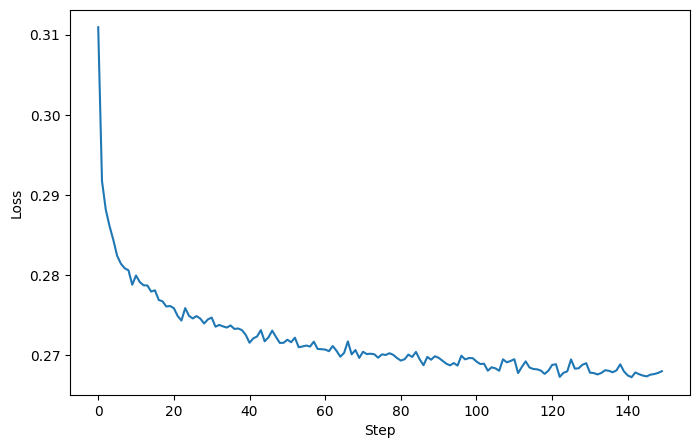

In [ ]:
plot_loss(loss_vals)

In [ ]:
test_dataset = TensorDataset(data.X_test_tensor, data.y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

model.eval()
running_val_loss = 0.0
correct = 0
total = 0

loop_val = tqdm(test_loader, desc="Ewaluacja")

with torch.no_grad():
    for input, label in loop_val:
        pred = model(input)

        loss = loss_function(pred, label.unsqueeze(1).float())
        running_val_loss += loss.item()

        predicted_classes = (pred > 0).float()

        correct += (predicted_classes == label.unsqueeze(1)).sum().item()
        total += label.size(0)

val_loss = running_val_loss / len(test_loader)
val_accuracy = (correct / total) * 100

print(f"\nVal Loss: {val_loss:.4f} | Val Accuracy: {val_accuracy:.2f}%")

Ewaluacja: 100%|██████████| 633/633 [00:00<00:00, 652.82it/s]


Val Loss: 0.2659 | Val Accuracy: 90.45%
